# Retail Database Design

In [1]:
! uv pip uninstall mermaid-python
! uv pip install -U mermaid-py

Using Python 3.14.7 environment at: C:\Users\ivang\Desktop\sandbox\sandbox\.venv
Using Python 3.14.7 environment at: C:\Users\ivang\Desktop\sandbox\sandbox\.venv
Resolved 6 packages in 409ms
Checked 6 packages in 1ms


In [2]:
from mermaid import Mermaid

In [3]:
from mermaid import Mermaid

diagram = """
erDiagram

    CUSTOMER {
        int customer_id
        string first_name
        string last_name
        string email
        string phone
    }

    CATEGORY {
        int category_id
        string category_name
    }

    PRODUCT {
        int product_id
        string product_name
        decimal price
        int stock_quantity
        int category_id
    }

    ORDER {
        int order_id
        date order_date
        decimal total_amount
        int customer_id
    }

    ORDER_ITEM {
        int order_item_id
        int order_id
        int product_id
        int quantity
        decimal unit_price
    }
"""

diagram_mm = Mermaid(diagram)
diagram_mm.to_png("retail-database-tables-only.png")
diagram_mm.to_svg("retail-database-tables-only.svg")

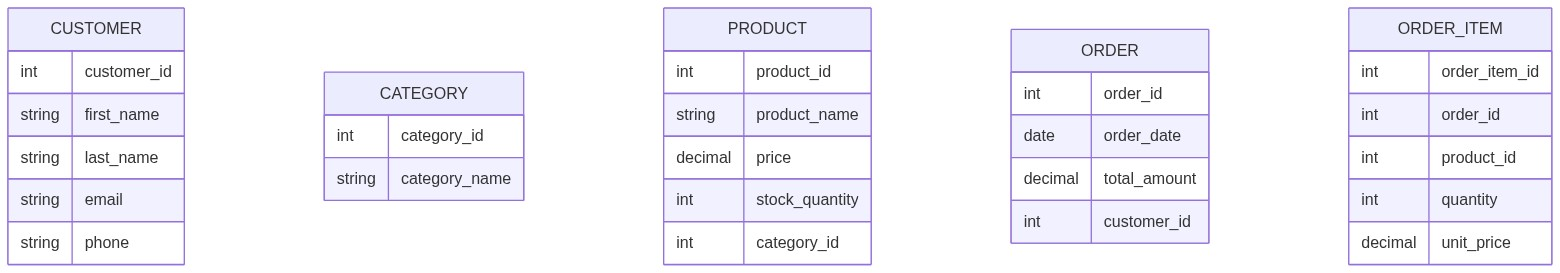

In [4]:
%%mermaidjs --img
erDiagram

    CUSTOMER {
        int customer_id
        string first_name
        string last_name
        string email
        string phone
    }

    CATEGORY {
        int category_id
        string category_name
    }

    PRODUCT {
        int product_id
        string product_name
        decimal price
        int stock_quantity
        int category_id
    }

    ORDER {
        int order_id
        date order_date
        decimal total_amount
        int customer_id
    }

    ORDER_ITEM {
        int order_item_id
        int order_id
        int product_id
        int quantity
        decimal unit_price
    }

You are desigining a retail database to track orders:

* A Customer places Order(s)
* An Order contains Order_Item(s)
* A Product is included in Order_Item(s)
* A Product belongs to a Category

Mark primary and foreign keys and add relationships, using craw's foot notation.

In [5]:
diagram = """
erDiagram

    CUSTOMER {
        int customer_id PK
        string first_name
        string last_name
        string email
        string phone
    }

    CATEGORY {
        int category_id PK
        string category_name
    }

    PRODUCT {
        int product_id PK
        string product_name
        decimal price
        int stock_quantity
        int category_id FK
    }

    ORDER {
        int order_id PK
        date order_date
        decimal total_amount
        int customer_id FK
    }

    ORDER_ITEM {
        int order_item_id PK
        int order_id FK
        int product_id FK
        int quantity
        decimal unit_price
    }

    CUSTOMER ||--o{ ORDER : places
    ORDER ||--|{ ORDER_ITEM : contains
    PRODUCT ||--o{ ORDER_ITEM : included_in
    CATEGORY ||--o{ PRODUCT : organizes
"""

diagram_mm = Mermaid(diagram)
diagram_mm.to_png("retail-database-solved.png")
diagram_mm.to_svg("retail-database-solved.svg")

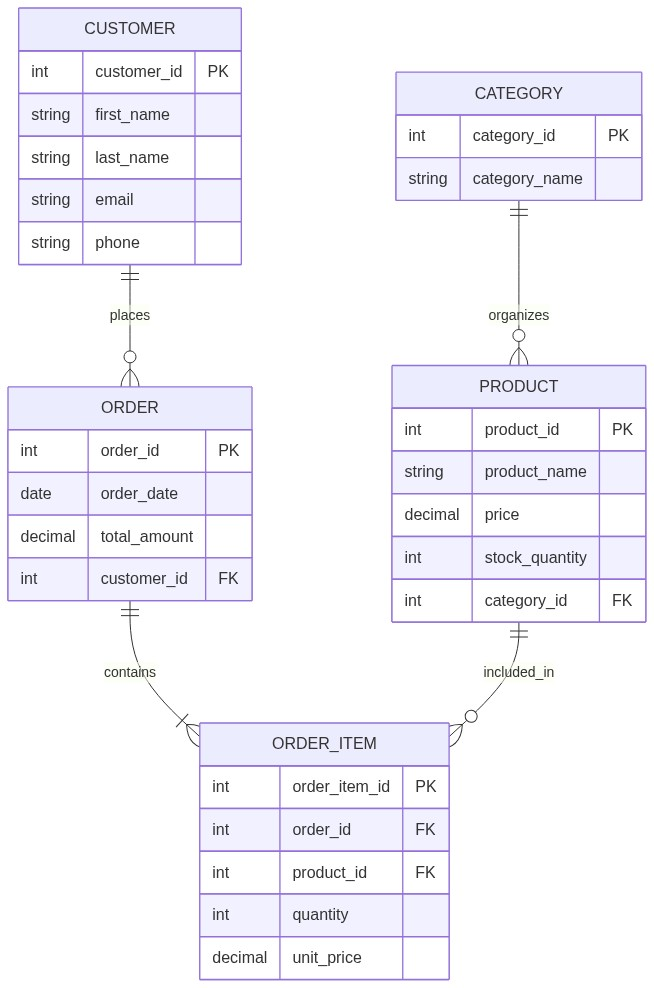

In [6]:
%%mermaidjs --img
erDiagram

    CUSTOMER {
        int customer_id PK
        string first_name
        string last_name
        string email
        string phone
    }

    CATEGORY {
        int category_id PK
        string category_name
    }

    PRODUCT {
        int product_id PK
        string product_name
        decimal price
        int stock_quantity
        int category_id FK
    }

    ORDER {
        int order_id PK
        date order_date
        decimal total_amount
        int customer_id FK
    }

    ORDER_ITEM {
        int order_item_id PK
        int order_id FK
        int product_id FK
        int quantity
        decimal unit_price
    }

    CUSTOMER ||--o{ ORDER : places
    ORDER ||--|{ ORDER_ITEM : contains
    PRODUCT ||--o{ ORDER_ITEM : included_in
    CATEGORY ||--o{ PRODUCT : organizes

## Resources
* [Add explanatory diagrams to your Python Data Science Projects with Mermaid.Js in VSCode](https://medium.com/@c_de_coronado/add-explanatory-diagrams-to-your-python-data-science-projects-with-mermaid-js-in-vscode-58418f59dcad)

## Render Mermaid Diagrams

### Render with Intermediate File

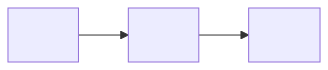

In [7]:
from mermaid import Mermaid

diagram = """
graph LR
    A --> B
    B --> C
"""

diagram_mm = Mermaid(diagram)
diagram_mm.to_png("retail-database-sample.png")
diagram_mm.to_svg("retail-database-sample.svg")

from IPython.display import SVG
SVG("retail-database-sample.svg")

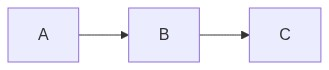

In [8]:
from IPython.display import Image
Image("retail-database-sample.png")

### Render using `mermaidjs` cell magic

(https://pypi.org/project/mermaid-py/)

In [9]:
%%mermaidjs
erDiagram

    CUSTOMER {
        int customer_id
        string first_name
        string last_name
        string email
        string phone
    }

    CATEGORY {
        int category_id
        string category_name
    }

    PRODUCT {
        int product_id
        string product_name
        decimal price
        int stock_quantity
        int category_id
    }

    ORDER {
        int order_id
        date order_date
        decimal total_amount
        int customer_id
    }

    ORDER_ITEM {
        int order_item_id
        int order_id
        int product_id
        int quantity
        decimal unit_price
    }

### Render using `mermaidjs` cell magic with `--img` flag

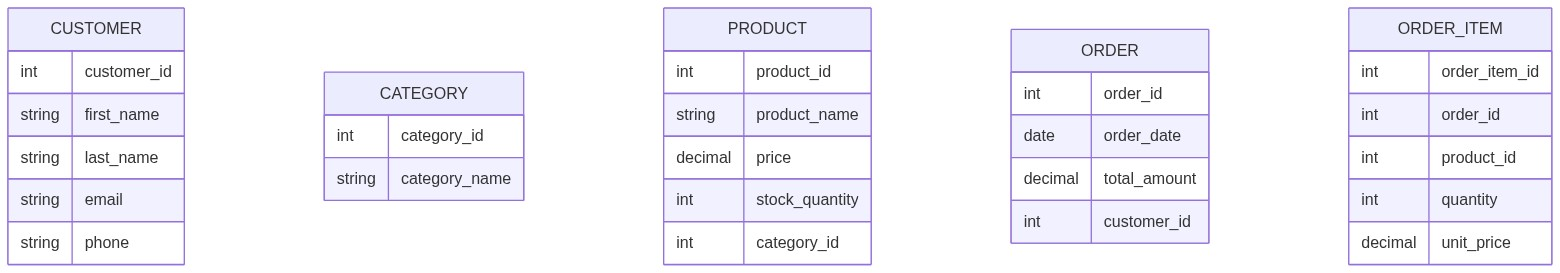

In [10]:
%%mermaidjs --img
erDiagram

    CUSTOMER {
        int customer_id
        string first_name
        string last_name
        string email
        string phone
    }

    CATEGORY {
        int category_id
        string category_name
    }

    PRODUCT {
        int product_id
        string product_name
        decimal price
        int stock_quantity
        int category_id
    }

    ORDER {
        int order_id
        date order_date
        decimal total_amount
        int customer_id
    }

    ORDER_ITEM {
        int order_item_id
        int order_id
        int product_id
        int quantity
        decimal unit_price
    }

### Render Using on-line image rendering

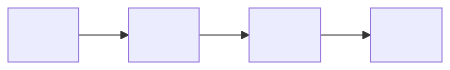

In [11]:
import base64
from IPython.display import display_svg
from urllib.request import Request, urlopen

def mm(graph):
    graphbytes = graph.encode("ascii")
    base64_bytes = base64.b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    url="https://mermaid.ink/svg/" + base64_string
    req=Request(url, headers={'User-Agent': 'IPython/Notebook'})
    display_svg(urlopen(req).read().decode(), raw=True)

mm("""
graph LR
   A --> B
   B --> C
   C --> D
""")

### Render Mermaid via HTML and JavaScript

In [12]:
from IPython.display import HTML

diagram = """
graph TD
    A --> B
    B --> C
    C --> D
"""

HTML(f"""
<div class="mermaid">
{diagram}
</div>

<script type="module">
import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@11/dist/mermaid.esm.min.mjs';
mermaid.initialize({{ startOnLoad: true }});
</script>
""")

### Render using HTML for JupyterLab 4+

In [13]:
from IPython.display import HTML

HTML("""
<pre class="mermaid">
graph TD
    A --> B
    B --> C
</pre>

<script type="module">
import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@11/dist/mermaid.esm.min.mjs';
mermaid.initialize({ startOnLoad: true });
</script>
""")

### Render Using Markdown Cell and Code Block

```mermaid
graph LR
    A --> B
    B --> C
```